In [34]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import mean_squared_error, structural_similarity

In [35]:
image = cv2.imread('data/sar_1_gray.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

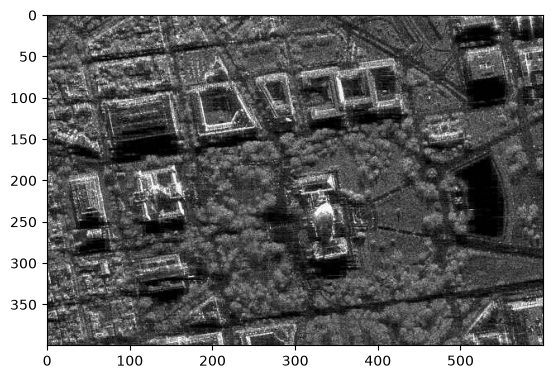

In [36]:
plt.imshow(image)

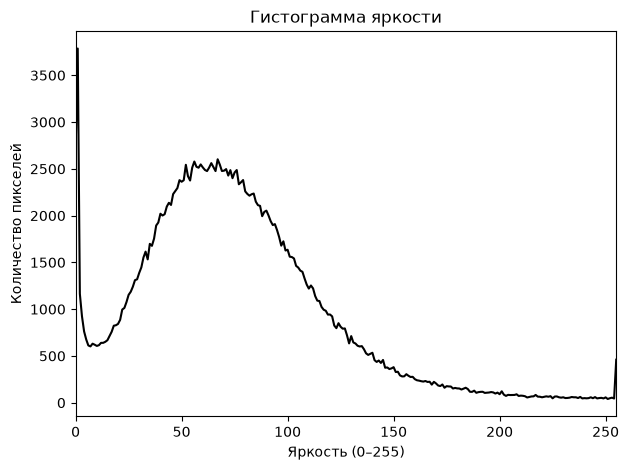

In [37]:
hist = cv2.calcHist([image],[0], None, [256], [0,256])
plt.plot(hist, color='black')
plt.title('Гистограмма яркости')
plt.xlabel('Яркость (0–255)')
plt.ylabel('Количество пикселей')
plt.xlim([0, 255])

plt.tight_layout()
plt.show()

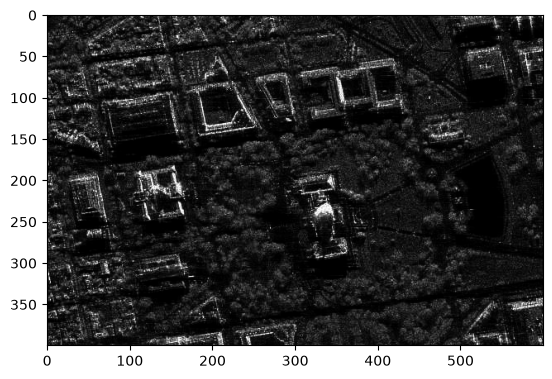

In [38]:
gamma1 = 2
lut= np.array([((i / 255.0) ** gamma1) * 255 for i in range(256)]).astype(np.uint8)
gamma_image1 = cv2.LUT(image, lut)
plt.imshow(gamma_image1)


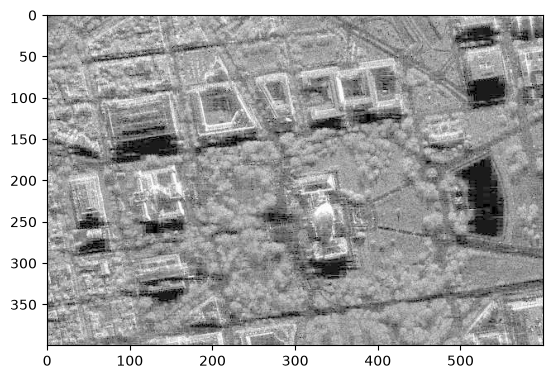

In [39]:
gamma2 = 0.4
lut= np.array([((i / 255.0) ** gamma2) * 255 for i in range(256)]).astype(np.uint8)
gamma_image2 = cv2.LUT(image, lut)
plt.imshow(gamma_image2)

In [42]:
mse  = mean_squared_error(gamma_image1, gamma_image2)
ssim = structural_similarity(gamma_image1, gamma_image2, data_range=255, channel_axis=-1)

In [43]:
mse

np.float64(14769.38905)

In [44]:
ssim

np.float64(0.2779758260298867)

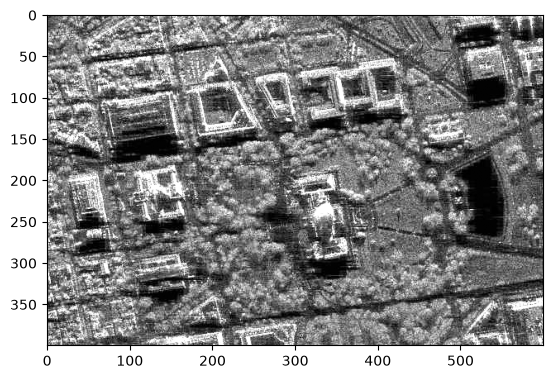

In [50]:
m_img, std_img = cv2.meanStdDev(gray)
m_img = m_img[0][0]
std_img = std_img[0][0]

m_target = 127.5
std_target = 64.0

img_corrected = ((gray.astype(np.float64) - m_img) / std_img) * std_target + m_target
img_corrected = np.clip(img_corrected, 0, 255).astype(np.uint8)

plt.imshow(img_corrected,cmap='gray')

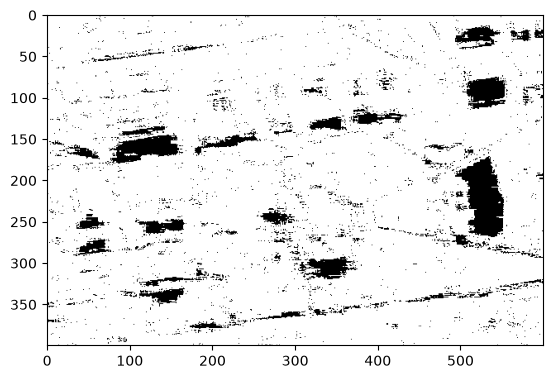

In [69]:
_, thresh_global = cv2.threshold(gray, 20, 255, cv2.THRESH_BINARY)
plt.imshow(thresh_global, cmap='gray')

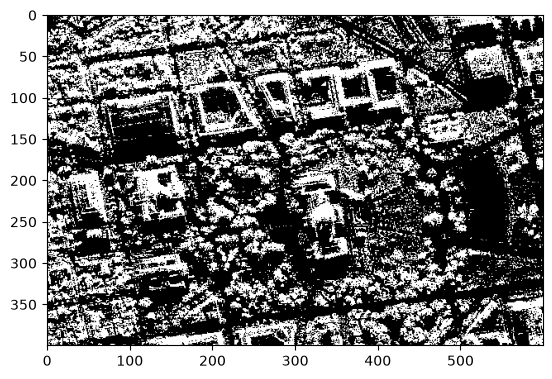

In [71]:
_, thresh_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(thresh_otsu, cmap='gray')

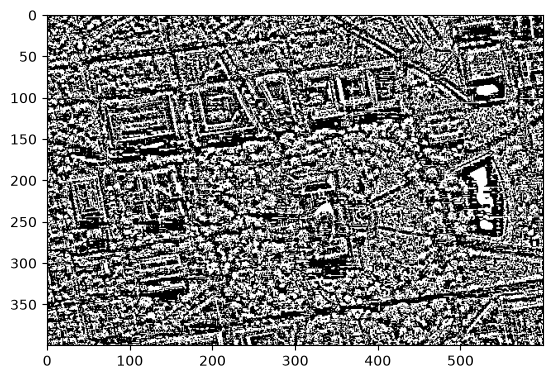

In [79]:
thresh_adaptive = cv2.adaptiveThreshold(
    img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 19, 0.5
)
plt.imshow(thresh_adaptive, cmap='gray')